In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [135]:
df = pd.read_csv("dataset/Installment_shorter_sampled.csv")
df.head(10)

,Asset ID,Origination Date,Total Advance,Total EMI,Payment Date,Payment Amount
0,264,1/31/2024,"17,160","20,540",2/7/2024,860
1,264,1/31/2024,"17,160","20,540",2/14/2024,860
2,264,1/31/2024,"17,160","20,540",2/21/2024,860
3,264,1/31/2024,"17,160","20,540",2/28/2024,860
4,264,1/31/2024,"17,160","20,540",3/6/2024,860
5,264,1/31/2024,"17,160","20,540",3/13/2024,860
6,264,1/31/2024,"17,160","20,540",3/20/2024,860
7,264,1/31/2024,"17,160","20,540",3/27/2024,860
8,264,1/31/2024,"17,160","20,540",4/3/2024,860
9,264,1/31/2024,"17,160","20,540",4/10/2024,"9,000"


In [136]:
#data inspection
print("Raw shape:", df.shape)
print("Raw size:",df.size) #size of the data
df.info()
print(df.columns.tolist())
print(df.isnull().sum())   # check missing values
print(df.nunique())    # check unique values per column
print(df.duplicated().sum())  # check duplicate count

Raw shape: (11894, 6)
Raw size: 71364
<class 'pandas.DataFrame'>
RangeIndex: 11894 entries, 0 to 11893
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Asset ID          11894 non-null  int64
 1   Origination Date  11894 non-null  str  
 2    Total Advance    11894 non-null  str  
 3    Total EMI        11894 non-null  str  
 4   Payment Date      11894 non-null  str  
 5    Payment Amount   11894 non-null  str  
dtypes: int64(1), str(5)
memory usage: 557.7 KB
['Asset ID', 'Origination Date', ' Total Advance ', ' Total EMI ', 'Payment Date', ' Payment Amount ']
Asset ID            0
Origination Date    0
 Total Advance      0
 Total EMI          0
Payment Date        0
 Payment Amount     0
dtype: int64
Asset ID            351
Origination Date    156
 Total Advance      165
 Total EMI          289
Payment Date        734
 Payment Amount     790
dtype: int64
638


In [137]:
#clean extra space from the column name
df.columns = [c.strip() for c in df.columns] #to avoid keyError
print(df.columns.tolist())
#check
df["Total Advance"]

['Asset ID', 'Origination Date', 'Total Advance', 'Total EMI', 'Payment Date', 'Payment Amount']


0         17,160 
1         17,160 
2         17,160 
3         17,160 
4         17,160 
           ...   
11889      8,249 
11890      8,249 
11891      8,249 
11892     16,499 
11893     16,499 
Name: Total Advance, Length: 11894, dtype: str

In [138]:
#remove commas, spaces and convert to numeric
def clean_numeric(series):
    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    cleaned = cleaned.replace("-", "0")    #"-" replace with 0 instead of dropping the whole column
    return pd.to_numeric(cleaned, errors="coerce")

df["Total Advance"] = clean_numeric(df["Total Advance"])
df["Total EMI"] = clean_numeric(df["Total EMI"])

#track how many installments were missed
missed_installments = (df["Payment Amount"].astype(str).str.strip() == "-").sum()
print(f"\nMissed/unpaid installment rows (recorded as '-'): {missed_installments}")

df["Payment Amount"] = clean_numeric(df["Payment Amount"])


Missed/unpaid installment rows (recorded as '-'): 4979


In [139]:
df["Payment Amount"].isnull().sum()  # check if any NaN remain

np.int64(0)

In [140]:
#check for numeric
print(df[["Total Advance", "Total EMI", "Payment Amount"]].dtypes)

Total Advance     int64
Total EMI         int64
Payment Amount    int64
dtype: object


In [141]:
#Convert date columns to datetime
df["Origination Date"] = pd.to_datetime(
    df["Origination Date"], format="%m/%d/%Y", errors="coerce"
)
df["Payment Date"] = pd.to_datetime(
    df["Payment Date"], format="%m/%d/%Y", errors="coerce"
)

#chevk
print(df[["Origination Date", "Payment Date"]].dtypes)

Origination Date    datetime64[us]
Payment Date        datetime64[us]
dtype: object


In [142]:
# remove exact duplicate rows
a = len(df)
df = df.drop_duplicates()
b = len(df)
print(f"Removed {a - b} exact duplicate rows")

Removed 638 exact duplicate rows


In [143]:
#Remove rows with invalid dates
a = len(df)
df = df.dropna(subset=["Origination Date", "Payment Date"])
b = len(df)
print(f"Removed {a - b} rows with invalid dates")

Removed 0 rows with invalid dates


In [144]:
#remove which payment date before origination date
before = len(df)
df = df[df["Payment Date"] >= df["Origination Date"]]
after = len(df)
print(f"Removed {before - after} rows where payment occurred before origination")

Removed 3 rows where payment occurred before origination


In [145]:
#check for outlier
df[["Total Advance", "Total EMI", "Payment Amount"]].describe()

,Total Advance,Total EMI,Payment Amount
count,11253.000000,11253.000000,11253.000000
mean,13072.591309,20282.096241,503.510175
std,3868.168687,6376.504288,721.823911
min,5760.000000,8100.000000,0.000000
25%,10050.000000,15381.000000,0.000000
50%,12920.000000,19910.000000,459.000000
75%,15840.000000,24300.000000,808.000000
max,29991.000000,48568.000000,16000.000000


Looks good and no extreme jump from 75% to max and aslo 25% for the min.

In [146]:
#Create cohort label (origination month) and elapsed month
df["Cohort"] = df["Origination Date"].dt.to_period("M").astype(str)

df["Elapsed Month"] = (
    (df["Payment Date"].dt.year - df["Origination Date"].dt.year) * 12
    + (df["Payment Date"].dt.month - df["Origination Date"].dt.month)
)

#save the copy
df_cleaned = df.copy()

In [147]:
#Also exclude cohorts that are clearly date-entry errors
cohort_loan_counts = df_cleaned.drop_duplicates(subset=["Asset ID"]).groupby("Cohort")["Asset ID"].nunique()
suspicious_cohorts = cohort_loan_counts[cohort_loan_counts <= 1].index.tolist()
if suspicious_cohorts:
    print(f"\nExcluding data-entry-error cohorts "
          f"outside main range): {suspicious_cohorts}")
    before = len(df_cleaned)
    df_cleaned = df_cleaned[~df_cleaned["Cohort"].isin(suspicious_cohorts)]
    print(f"Removed {before - len(df_cleaned)} rows from these cohorts")

#save this as csv
df_cleaned.to_csv("output/cleaned_installments.csv", index=False)
print("\nCleaned dataset saved")
print("Cleaned shape:", df_cleaned.shape)


Excluding data-entry-error cohorts outside main range): ['2025-09', '2025-10', '2026-01']
Removed 32 rows from these cohorts

Cleaned dataset saved
Cleaned shape: (11221, 8)


In [148]:
#total Advance per cohort
cohort_advance = (
    df_cleaned.drop_duplicates(subset=["Asset ID"])
    .groupby("Cohort")["Total Advance"]
    .sum()
    .rename("Cohort Total Advance")
)

print("\nTotal Advance per cohort:")
print(cohort_advance)


Total Advance per cohort:
Cohort
2024-01    102945
2024-02    136095
2024-03    795665
2024-04    368935
2024-05    224805
2024-06    447855
2024-07    286900
2024-08    325990
2024-09    408306
2024-10    461204
2024-11    634639
2024-12    267439
Name: Cohort Total Advance, dtype: int64


In [149]:
#Aggregate payments
payment_by_period = (
    df_cleaned.groupby(["Cohort", "Elapsed Month"])["Payment Amount"] #Cohort + Elapsed Month
    .sum()
    .reset_index()
    .rename(columns={"Payment Amount": "Period Payment"})
)

In [150]:
#Calculate Cumulative Payments and MOIC
payment_by_period = payment_by_period.sort_values(["Cohort", "Elapsed Month"])

payment_by_period["Cumulative Payment"] = (
    payment_by_period.groupby("Cohort")["Period Payment"].cumsum()
)

payment_by_period = payment_by_period.merge(
    cohort_advance, on="Cohort", how="left"
)

payment_by_period["Payment MOIC"] = (
    payment_by_period["Period Payment"] / payment_by_period["Cohort Total Advance"]
).round(4)

payment_by_period["Cumulative MOIC"] = (
    payment_by_period["Cumulative Payment"] / payment_by_period["Cohort Total Advance"]
).round(4)

print("\nSample of cohort performance table:")
print(payment_by_period.head(15))


Sample of cohort performance table:
     Cohort  Elapsed Month  Period Payment  Cumulative Payment  \
0   2024-01              1           23498               23498   
1   2024-01              2           24097               47595   
2   2024-01              3           39580               87175   
3   2024-01              4           12689               99864   
4   2024-01              5           11843              111707   
5   2024-01              6            4950              116657   
6   2024-01              9            2493              119150   
7   2024-02              0            7520                7520   
8   2024-02              1           31246               38766   
9   2024-02              2           35183               73949   
10  2024-02              3           28064              102013   
11  2024-02              4           32951              134964   
12  2024-02              5           28595              163559   
13  2024-02              6           13

In [151]:
#make cohort summary table
cohort_summary = payment_by_period.pivot(
    index="Cohort", columns="Elapsed Month", values="Cumulative MOIC"
)

# Forward-fill so MOIC doesn't drop to NaN/blank after the last payment
cohort_summary = cohort_summary.sort_index(axis=1).ffill(axis=1)

cohort_summary.to_csv("output/cohort_summary.csv")
print("\nCohort summary table saved!")
print(cohort_summary.round(2))


Cohort summary table saved!
Elapsed Month    0     1     2     3     4     5     6     7     8     9   \
Cohort                                                                      
2024-01         NaN  0.23  0.46  0.85  0.97  1.09  1.13  1.13  1.13  1.16   
2024-02        0.06  0.28  0.54  0.75  0.99  1.20  1.30  1.30  1.33  1.33   
2024-03        0.10  0.33  0.56  0.78  0.98  1.17  1.21  1.26  1.28  1.28   
2024-04        0.10  0.36  0.58  0.80  1.03  1.21  1.28  1.31  1.33  1.33   
2024-05        0.08  0.32  0.54  0.74  0.95  1.19  1.29  1.30  1.30  1.31   
2024-06        0.14  0.35  0.59  0.78  0.97  1.11  1.20  1.24  1.25  1.26   
2024-07        0.14  0.38  0.61  0.84  1.03  1.26  1.27  1.31  1.31  1.33   
2024-08        0.05  0.29  0.54  0.76  0.98  1.20  1.30  1.32  1.32  1.33   
2024-09        0.08  0.32  0.54  0.79  0.99  1.17  1.30  1.32  1.34  1.35   
2024-10        0.09  0.34  0.60  0.82  0.99  1.15  1.22  1.25  1.26  1.27   
2024-11        0.08  0.28  0.45  0.59  0.72  0.

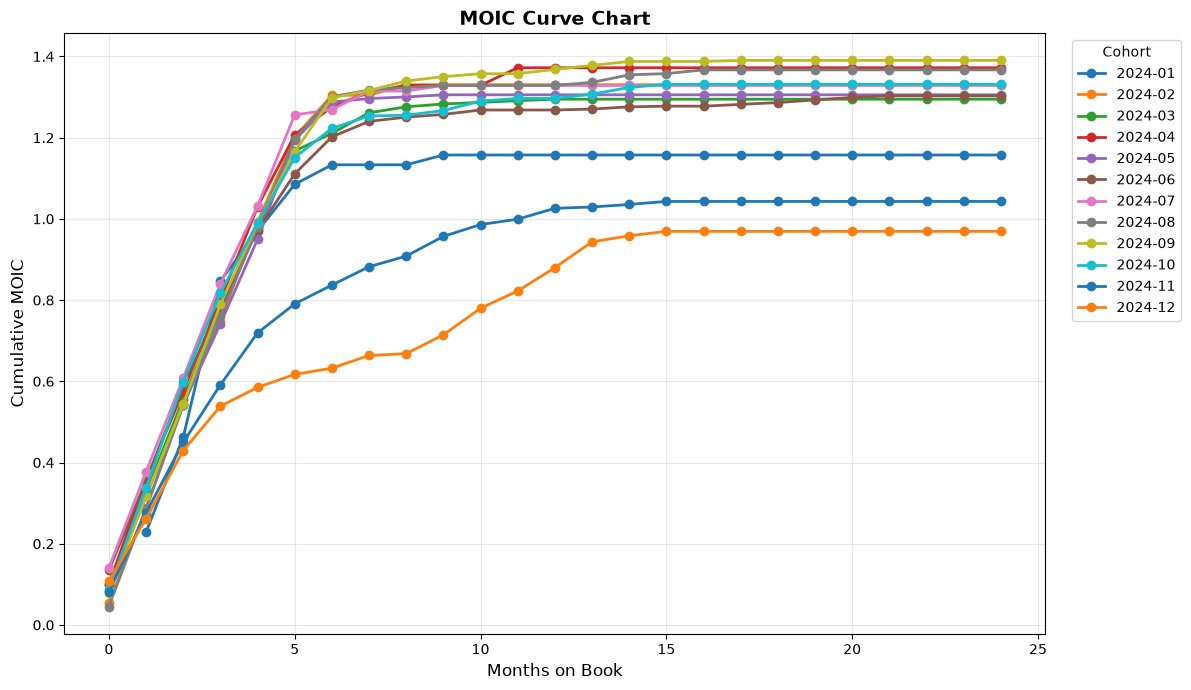


Chart saved!


In [152]:
#Plot the MOIC Curve
plt.figure(figsize=(12, 7))

for cohort in cohort_summary.index:
    series = cohort_summary.loc[cohort].dropna()
    plt.plot(series.index, series.values, marker="o", label=cohort, linewidth=2) #plooting

#label define
plt.title("MOIC Curve Chart", fontsize=14, fontweight="bold")
plt.xlabel("Months on Book", fontsize=12)
plt.ylabel("Cumulative MOIC", fontsize=12)
plt.legend(title="Cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/moic_curve.png", dpi=200)
plt.show()

print("\nChart saved!")

Analysis:
The cumulative MOIC is initially zero because no repayments have been received when the loan is originated. The cumulative MOIC rises sharply within the initial six months, due to repayments from the borrowers. The cumulative MOIC then becomes flat from six to eight months as most of the loans mature. The cumulative MOIC is finally flat because repayments previously received contribute to the cumulative total.

And also 2024-09 is the best performer. Because it reaches the highest plateau around 1.39x